# Results by Köppen-Geiger Climate Class

Loads **all** `results.json` files found under `regions/`, assigns each catchment its
dominant Köppen-Geiger class (highest coverage %), and visualises how the once-in-100-year
discharge shifts across climate scenarios — grouped and coloured by KG class.

In [9]:
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

from rich import print

# ── Scenario display order (same as preliminary_results) ──────────────────────
SCENARIO_ORDER = [
    'CMIP6 hist',
    'ERA5',
    'DestinE hist',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP5-8.5',
    'DestinE future',
]

# ── Major KG group colours (standard palette) ─────────────────────────────────
KG_GROUP_COLOR = {
    'A': '#1565C0',   # Tropical  — blue
    'B': '#E65100',   # Arid      — deep orange
    'C': '#2E7D32',   # Temperate — green
    'D': '#6A1B9A',   # Continental — purple
    'E': '#00838F',   # Polar     — teal
}
KG_GROUP_LABEL = {
    'A': 'A — Tropical',
    'B': 'B — Arid',
    'C': 'C — Temperate',
    'D': 'D — Continental',
    'E': 'E — Polar',
}

## 1. Load all results

In [10]:
def parse_rp(value):
    """Return (mean, std) for a return-period value (plain number or 'mean ± std' string)."""
    if isinstance(value, (int, float)):
        return float(value), 0.0
    s = str(value)
    if '\u00b1' in s:
        parts = s.split('\u00b1')
        return float(parts[0].strip()), float(parts[1].strip())
    return float(s.strip()), 0.0


def get_scenario_label(key):
    """Map a results.json key to a short display label and display order."""
    k = key.lower()
    if 'modelled discharge' in k or ('cmip' in k and 'ssp' not in k):
        return 'CMIP6 hist', 0
    if k == 'era5':
        return 'ERA5', 1
    if 'destine' in k and ('hist' in k or 'historical' in k):
        return 'DestinE hist', 2
    if 'ssp126' in k:
        return 'SSP1-2.6', 3
    if 'ssp245' in k:
        return 'SSP2-4.5', 4
    if 'ssp370' in k:
        return 'SSP3-7.0', 5
    if 'ssp585' in k:
        return 'SSP5-8.5', 6
    if 'destine' in k:
        return 'DestinE future', 7
    return None, 99


def dominant_kg(kg_dict):
    """Return the KG class code with the highest catchment coverage."""
    return max(kg_dict, key=kg_dict.get)


# ── Walk every region directory ───────────────────────────────────────────────
base_path = Path('regions')
all_results = []
skipped = []

for results_file in sorted(base_path.rglob('results.json')):
    country = results_file.parts[-3]   # regions/<country>/<region>/results.json
    region  = results_file.parts[-2]

    with open(results_file) as f:
        data = json.load(f)

    # Minimum required keys
    if not {'return_periods_HBV', 'return_periods_leakybucket', 'koppen_geiger', 'catchment_area_km2'} <= data.keys():
        skipped.append(f"{country}/{region}  (missing required keys)")
        # print(f'[red]✗[/red] {country:30s} / {region}  [dim](incomplete)[/dim]')
        continue

    if 'observed_reference' not in data['return_periods_leakybucket']:
        skipped.append(f"{country}/{region}  (no observed_reference)")
        # print(f'[red]✗[/red] {country:30s} / {region}  [dim](no observed_reference)[/dim]')
        continue

    if 'observed_reference' not in data['return_periods_HBV']:
        skipped.append(f"{country}/{region}  (no observed_reference)")
        # print(f'[red]✗[/red] {country:30s} / {region}  [dim](no observed_reference)[/dim]')
        continue

    data['country'] = country
    data['region']  = region
    data['kg_dominant'] = dominant_kg(data['koppen_geiger'])
    data['kg_group']    = data['kg_dominant'][0]   # first letter: A/B/C/D/E
    all_results.append(data)
    # print(f'[green]✓[/green] {country:30s} / {region}  '
    #       f'[cyan]{data["kg_dominant"]}[/cyan]')

print(f'\n[bold]{len(all_results)} region(s) loaded.[/bold]')
# if skipped:
#     print(f'[yellow]{len(skipped)} skipped:[/yellow]')
#     for s in skipped:
#         print(f'  [dim]· {s}[/dim]')

23 region(s) loaded.

## 2. Build DataFrame

In [15]:
rows = []
for r in all_results:
    for model_name, rp_key in [('HBV', 'return_periods_HBV'), 
                                ('LeakyBucket', 'return_periods_leakybucket')]:
        if rp_key not in r:
            continue
        rp_dict = r[rp_key]
        obs = rp_dict['observed_reference']
        q100_mm_d = float(obs.get('q100_mm_d', 0.0))
        for key, vals in rp_dict.items():
            if key == 'observed_reference':
                continue
            rp_val = vals.get('rp_at_obs_q100') if isinstance(vals, dict) else None
            if rp_val is None:
                continue
            label, order = get_scenario_label(key)
            if label is None:
                continue
            mean, std = parse_rp(rp_val)
            rows.append({
                'country':            r['country'],
                'region':             r['region'],
                'caravan_id':         r['caravan_id'],
                'catchment_area_km2': r['catchment_area_km2'],
                'kg_dominant':        r['kg_dominant'],
                'kg_group':           r['kg_group'],
                'model':              model_name,
                'scenario_label':     label,
                'order':              order,
                'rp_mean':            mean,
                'rp_std':             std,
                'q100_mm_d':          q100_mm_d,
                'q100_m3s':           q100_mm_d * r['catchment_area_km2'] / 86.4,
            })

df = (pd.DataFrame(rows)
        .sort_values(['kg_group', 'kg_dominant', 'region', 'model', 'order'])
        .reset_index(drop=True))
print(df[['country', 'region', 'kg_dominant', 'model', 'scenario_label', 'rp_mean']].to_string())

country             region kg_dominant        model  scenario_label       rp_mean
0                   australia  camelsaus_102101A          Aw          HBV      CMIP6 hist  6.360000e+00
1                   australia  camelsaus_102101A          Aw          HBV            ERA5  6.820000e+00
2                   australia  camelsaus_102101A          Aw          HBV    DestinE hist  1.059000e+01
3                   australia  camelsaus_102101A          Aw          HBV        SSP1-2.6  5.210000e+00
4                   australia  camelsaus_102101A          Aw          HBV        SSP2-4.5  5.200000e+00
5                   australia  camelsaus_102101A          Aw          HBV        SSP3-7.0  4.730000e+00
6                   australia  camelsaus_102101A          Aw          HBV        SSP5-8.5  4.600000e+00
7                   australia  camelsaus_102101A          Aw          HBV  DestinE future  3.850000e+00
8                   australia  camelsaus_102101A          Aw  LeakyBucket      CMIP6 hist  2.850000e+00
9                   australia  camelsaus_102101A          Aw  LeakyBucket            ERA5  4.130000e+00
10                  australia  camelsaus_102101A          Aw  LeakyBucket    DestinE hist  5.550000e+00
11                  australia  camelsaus_102101A          Aw  LeakyBucket        SSP1-2.6  3.150000e+00
12                  australia  camelsaus_102101A          Aw  LeakyBucket        SSP2-4.5  3.280000e+00
13                  australia  camelsaus_102101A          Aw  LeakyBucket        SSP3-7.0  3.290000e+00
14                  australia  camelsaus_102101A          Aw  LeakyBucket        SSP5-8.5  3.080000e+00
15                  australia  camelsaus_102101A          Aw  LeakyBucket  DestinE future  2.880000e+00
16                  australia  camelsaus_104001A          Aw          HBV      CMIP6 hist  2.741000e+01
17                  australia  camelsaus_104001A          Aw          HBV            ERA5  4.902000e+01
18                  australia  camelsaus_104001A          Aw          HBV    DestinE hist  4.573000e+01
19                  australia  camelsaus_104001A          Aw          HBV        SSP1-2.6  1.506000e+01
20                  australia  camelsaus_104001A          Aw          HBV        SSP2-4.5  1.181000e+01
21                  australia  camelsaus_104001A          Aw          HBV        SSP3-7.0  1.348000e+01
22                  australia  camelsaus_104001A          Aw          HBV        SSP5-8.5  1.359000e+01
23                  australia  camelsaus_104001A          Aw          HBV  DestinE future  1.521000e+01
24                  australia  camelsaus_104001A          Aw  LeakyBucket      CMIP6 hist  4.104000e+01
25                  australia  camelsaus_104001A          Aw  LeakyBucket            ERA5  1.898800e+02
26                  australia  camelsaus_104001A          Aw  LeakyBucket    DestinE hist  2.111900e+02
27                  australia  camelsaus_104001A          Aw  LeakyBucket        SSP1-2.6  4.761000e+01
28                  australia  camelsaus_104001A          Aw  LeakyBucket        SSP2-4.5  3.545000e+01
29                  australia  camelsaus_104001A          Aw  LeakyBucket        SSP3-7.0  5.256000e+01
30                  australia  camelsaus_104001A          Aw  LeakyBucket        SSP5-8.5  4.582000e+01
31                  australia  camelsaus_104001A          Aw  LeakyBucket  DestinE future  9.763000e+01
32                  australia  camelsaus_105102A          Aw          HBV      CMIP6 hist  8.220000e+00
33                  australia  camelsaus_105102A          Aw          HBV            ERA5  6.820000e+00
34                  australia  camelsaus_105102A          Aw          HBV    DestinE hist  7.280000e+00
35                  australia  camelsaus_105102A          Aw          HBV        SSP1-2.6  5.550000e+00
36                  australia  camelsaus_105102A          Aw          HBV        SSP2-4.5  5.760000e+00
37                  australia  camelsaus_105102A          Aw          

## 3. Plot — return-period shift, coloured by KG group

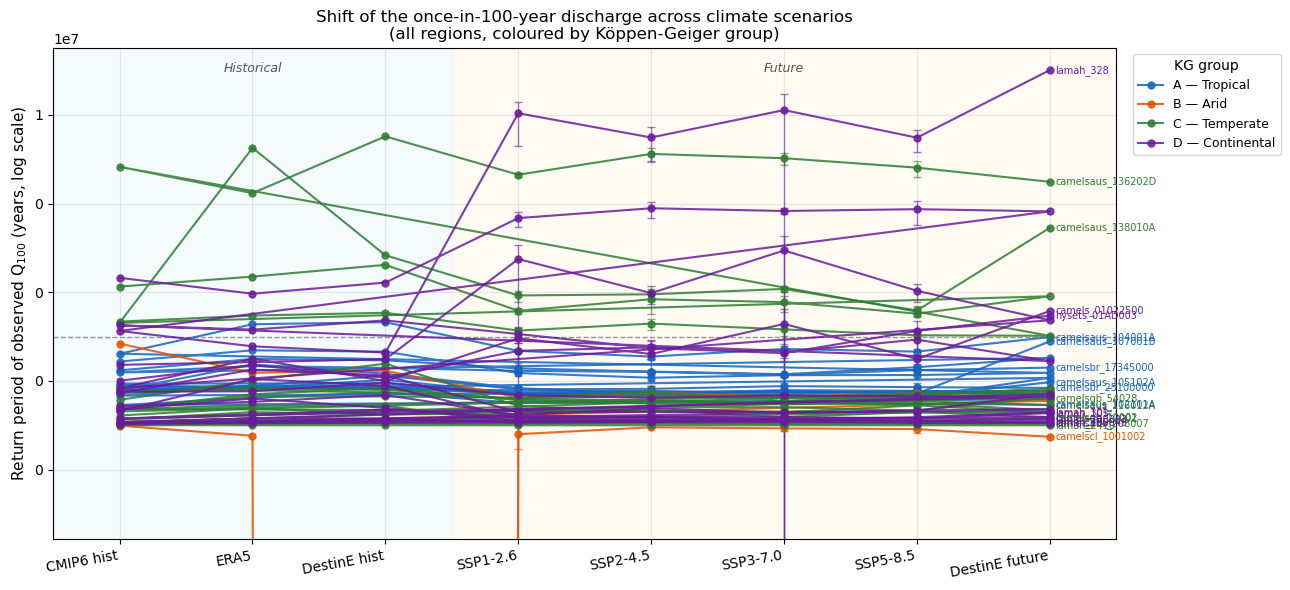

In [16]:
label_to_x = {lbl: i for i, lbl in enumerate(SCENARIO_ORDER)}

fig, ax = plt.subplots(figsize=(13, 6))

# Log scale — keeps extreme outliers visible without squashing the rest
ax.set_yscale('log')
ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)

# Shaded background: historical / future
ax.axvspan(-0.5, 2.5, color='#e8f4f8', alpha=0.4, zorder=0)
ax.axvspan(2.5, len(SCENARIO_ORDER) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
ax.text(1.0, 0.97, 'Historical', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')
ax.text(5.0, 0.97, 'Future', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')

# One line per region, colour = KG major group
plotted_groups = set()
for (region, kg_group), grp in df.groupby(['region', 'kg_group'], sort=False):
    color = KG_GROUP_COLOR.get(kg_group, '#888888')
    x_vals, y_vals, y_errs = [], [], []
    for _, row in grp.iterrows():
        if row['scenario_label'] in label_to_x:
            x_vals.append(label_to_x[row['scenario_label']])
            y_vals.append(row['rp_mean'])
            y_errs.append(row['rp_std'])

    kg_label = KG_GROUP_LABEL.get(kg_group, kg_group)
    ax.plot(x_vals, y_vals, 'o-', color=color, linewidth=1.5, markersize=5,
            label=kg_label if kg_group not in plotted_groups else '_nolegend_',
            alpha=0.85, zorder=3)
    plotted_groups.add(kg_group)

    for x, y, ye in zip(x_vals, y_vals, y_errs):
        if ye > 0:
            ax.errorbar(x, y, yerr=ye, fmt='none', ecolor=color,
                        elinewidth=1.0, capsize=3, alpha=0.6, zorder=2)

    # Annotate the region name at the rightmost point
    if x_vals:
        ax.annotate(
            grp['region'].iloc[0],
            xy=(x_vals[-1], y_vals[-1]),
            xytext=(4, 0), textcoords='offset points',
            fontsize=7, color=color, va='center',
        )

ax.set_xticks(range(len(SCENARIO_ORDER)))
ax.set_xticklabels(SCENARIO_ORDER, fontsize=10, rotation=10, ha='right')
ax.set_ylabel('Return period of observed Q$_{100}$ (years, log scale)', fontsize=11)
ax.set_title(
    'Shift of the once-in-100-year discharge across climate scenarios\n'
    '(all regions, coloured by Köppen-Geiger group)',
    fontsize=12,
)
ax.set_xlim(-0.5, len(SCENARIO_ORDER) - 0.5)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(title='KG group', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.show()

## 4. Plot per KG group

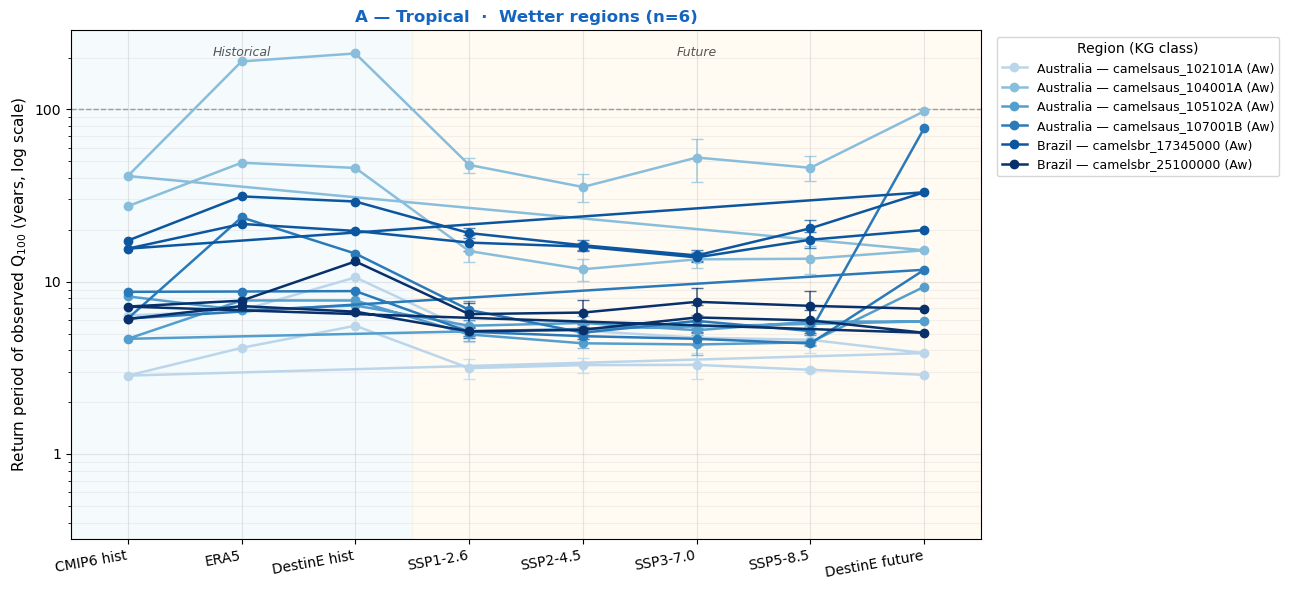

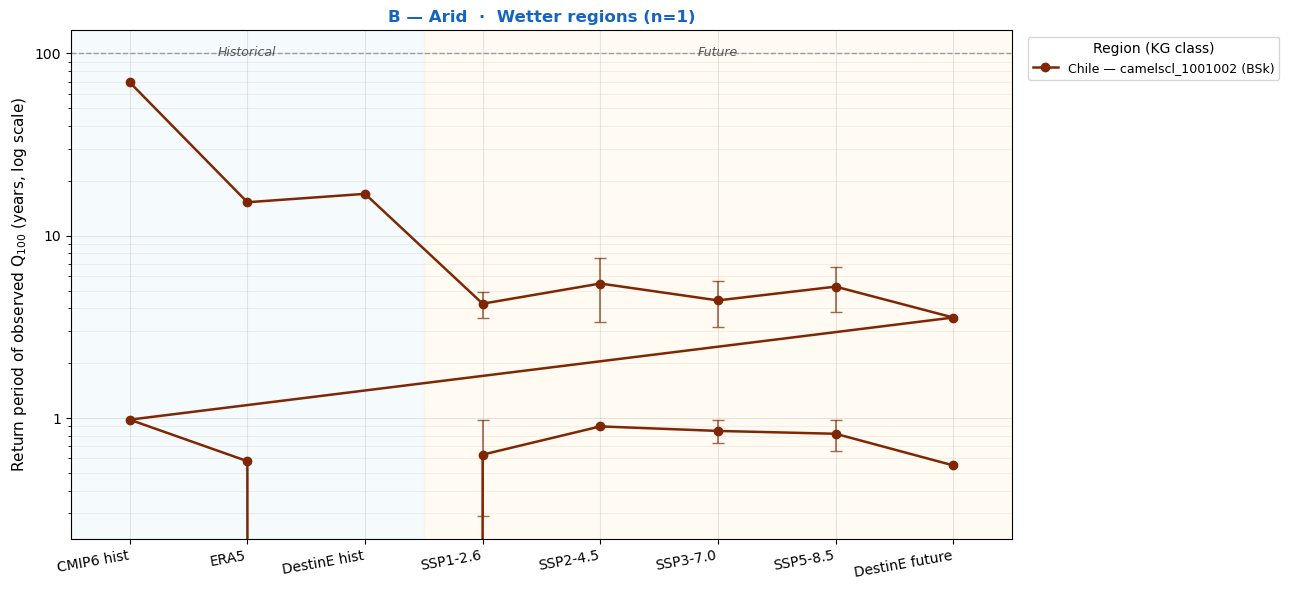

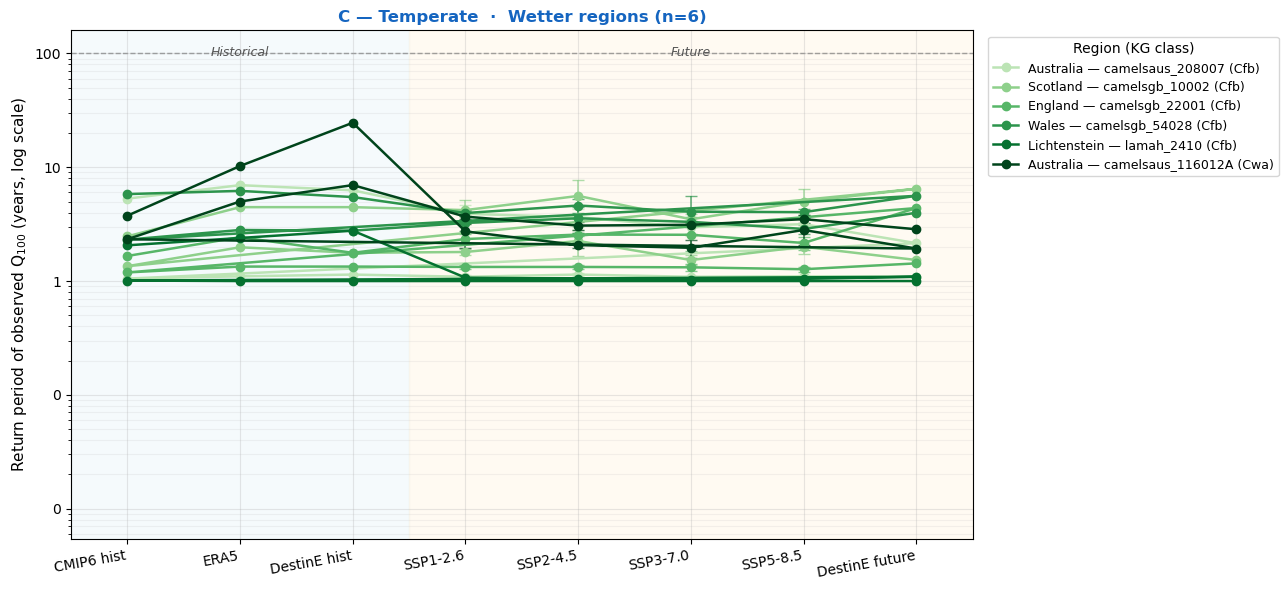

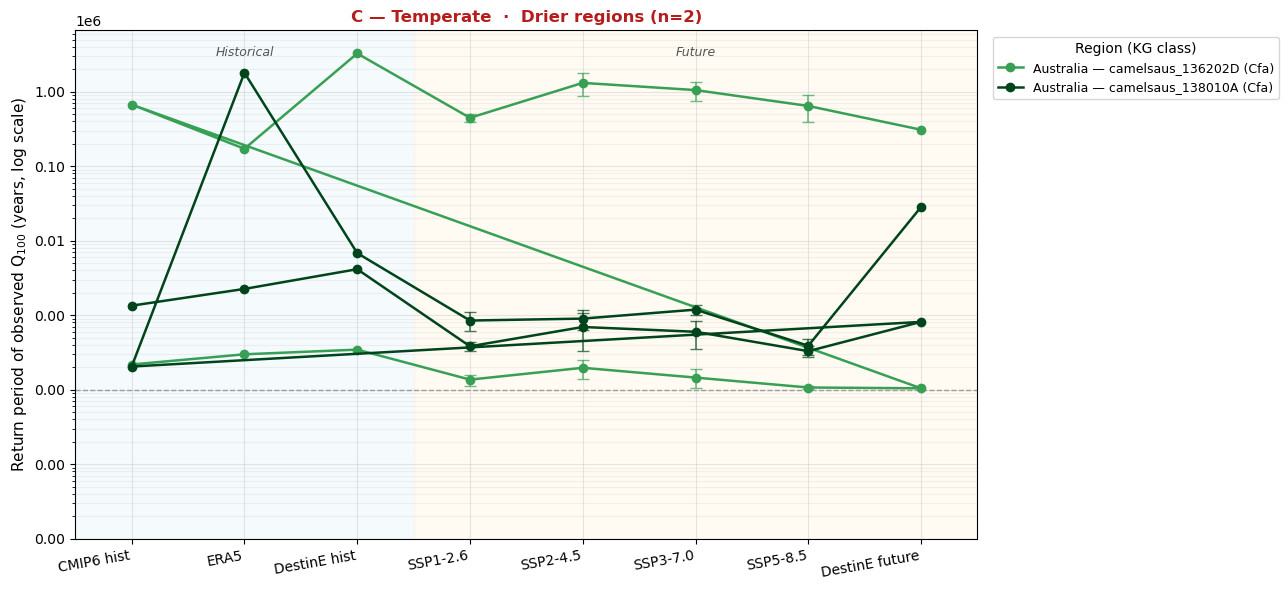

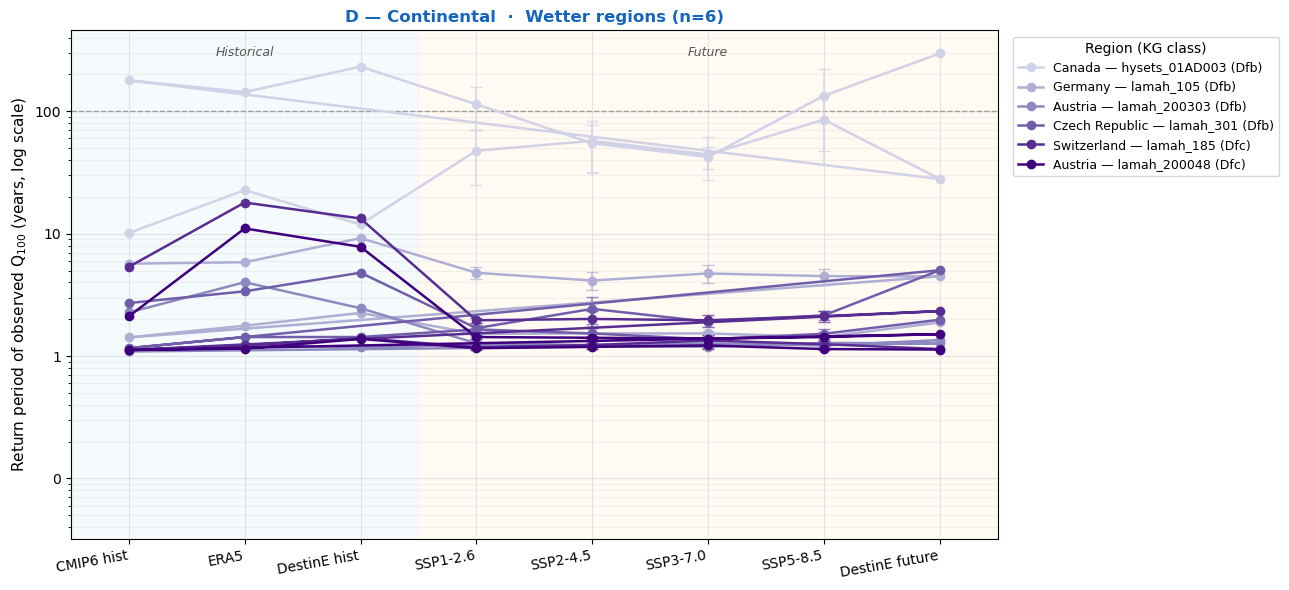

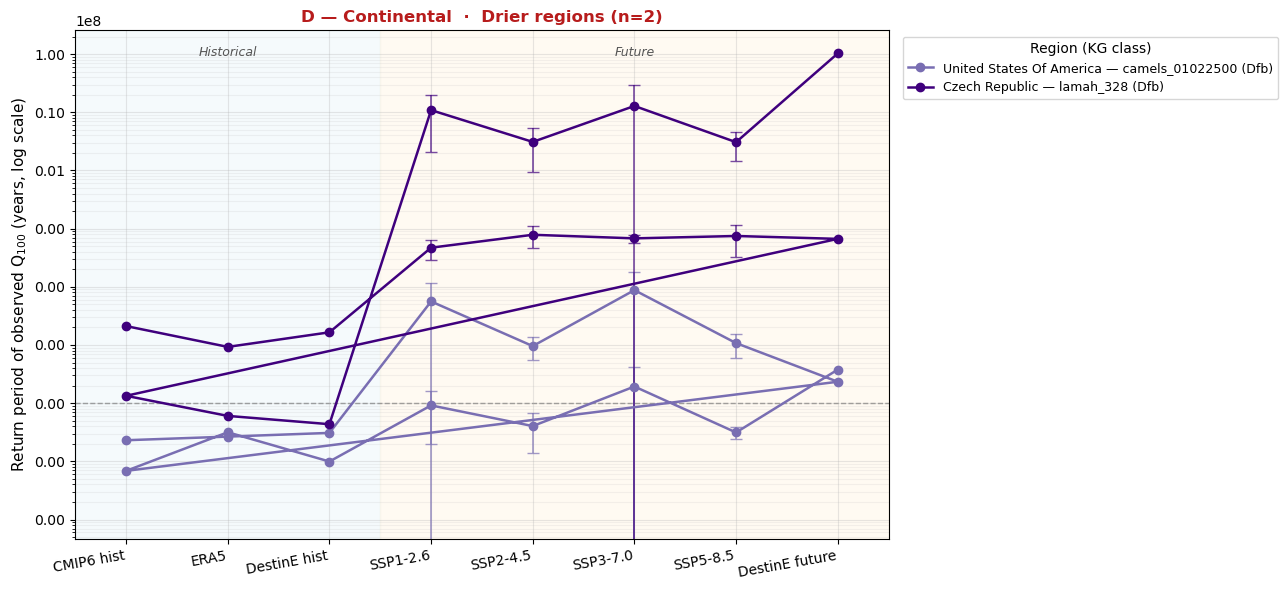

In [17]:
FUTURE_SCENARIOS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5', 'DestinE future']

# Classify each region as Wetter (mean future RP < 100) or Drier (>= 100)
mean_future = (
    df[df['scenario_label'].isin(FUTURE_SCENARIOS)]
    .groupby('region')['rp_mean']
    .mean()
)
df['direction'] = df['region'].map(mean_future).apply(
    lambda x: 'Wetter' if x < 100 else 'Drier'
)

kg_groups_present = sorted(df['kg_group'].unique())

for kg_group in kg_groups_present:
    for direction in ['Wetter', 'Drier']:
        subset = df[(df['kg_group'] == kg_group) & (df['direction'] == direction)]
        if subset.empty:
            continue

        regions = subset['region'].unique()
        color   = KG_GROUP_COLOR.get(kg_group, '#888888')

        cmap = plt.cm.get_cmap(
            'Blues'   if kg_group == 'A' else
            'Oranges' if kg_group == 'B' else
            'Greens'  if kg_group == 'C' else
            'Purples' if kg_group == 'D' else 'GnBu',
            len(regions) + 2,
        )
        region_colors = {r: cmap(i + 2) for i, r in enumerate(regions)}

        dir_color = '#1565C0' if direction == 'Wetter' else '#B71C1C'

        fig, ax = plt.subplots(figsize=(13, 6))

        # Log scale — keeps extreme outliers visible without squashing the rest
        ax.set_yscale('log')
        ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)
        ax.axvspan(-0.5, 2.5, color='#e8f4f8', alpha=0.4, zorder=0)
        ax.axvspan(2.5, len(SCENARIO_ORDER) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
        ax.text(1.0, 0.97, 'Historical', transform=ax.get_xaxis_transform(),
                ha='center', va='top', color='#555', fontsize=9, style='italic')
        ax.text(5.0, 0.97, 'Future', transform=ax.get_xaxis_transform(),
                ha='center', va='top', color='#555', fontsize=9, style='italic')

        for region, rgrp in subset.groupby('region', sort=False):
            rc = region_colors[region]
            x_vals, y_vals, y_errs = [], [], []
            for _, row in rgrp.iterrows():
                if row['scenario_label'] in label_to_x:
                    x_vals.append(label_to_x[row['scenario_label']])
                    y_vals.append(row['rp_mean'])
                    y_errs.append(row['rp_std'])

            kg_code = rgrp['kg_dominant'].iloc[0]
            country = rgrp['country'].iloc[0].replace('_', ' ').title()
            ax.plot(x_vals, y_vals, 'o-', color=rc, linewidth=1.8, markersize=6,
                    label=f"{country} — {region} ({kg_code})", zorder=3)
            for x, y, ye in zip(x_vals, y_vals, y_errs):
                if ye > 0:
                    ax.errorbar(x, y, yerr=ye, fmt='none', ecolor=rc,
                                elinewidth=1.2, capsize=4, alpha=0.7, zorder=2)

        ax.set_xticks(range(len(SCENARIO_ORDER)))
        ax.set_xticklabels(SCENARIO_ORDER, fontsize=10, rotation=10, ha='right')
        ax.set_ylabel('Return period of observed Q$_{100}$ (years, log scale)', fontsize=11)
        ax.set_title(
            f'{KG_GROUP_LABEL.get(kg_group, kg_group)}  ·  '
            f'{direction} regions (n={len(regions)})',
            fontsize=12, color=dir_color, fontweight='bold',
        )
        ax.set_xlim(-0.5, len(SCENARIO_ORDER) - 0.5)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
        ax.grid(True, which='major', alpha=0.3)
        ax.grid(True, which='minor', alpha=0.15)
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
                  framealpha=0.8, title='Region (KG class)')

        plt.tight_layout()
        plt.show()

## 5. Summary table — mean return period per KG group × scenario

In [18]:
pivot = df.pivot_table(
    index='kg_dominant',
    columns='scenario_label',
    values='rp_mean',
    aggfunc='mean',
)
present_cols = [c for c in SCENARIO_ORDER if c in pivot.columns]
pivot = pivot[present_cols]

# Add region count and KG group letter as context columns
counts = df.groupby('kg_dominant')['region'].nunique().rename('n_regions')
pivot.insert(0, 'n_regions', counts)

pivot.index.name = 'KG class (dominant)'

pivot.style \
    .format({'n_regions': '{:.0f}'}) \
    .format({c: '{:.1f}' for c in present_cols}) \
    .background_gradient(cmap='RdYlGn_r', subset=present_cols, axis=None, vmin=50, vmax=200) \
    .set_caption(
        'Mean return period (years) of the observed Q\u2081\u2080\u2080 discharge '
        'per dominant KG class — > 100 \u2192 rarer event; < 100 \u2192 more frequent'
    )

scenario_label,n_regions,CMIP6 hist,ERA5,DestinE hist,SSP1-2.6,SSP2-4.5,SSP3-7.0,SSP5-8.5,DestinE future
KG class (dominant),,,,,,,,,
Aw,6,12.6,30.4,31.7,11.8,10.0,11.3,11.5,24.1
BSk,1,35.2,7.9,8.3,2.4,3.2,2.6,3.0,2.1
Cfa,2,168920.5,494589.7,821585.4,112238.0,330114.4,264359.5,161741.7,84730.8
Cfb,5,2.4,3.1,2.9,2.4,2.7,2.2,2.4,2.9
Cwa,1,3.0,7.6,15.8,3.2,2.6,2.5,3.2,2.4
Dfb,6,206.7,102.5,166.7,912033.9,264551.5,1076656.7,261673.5,8554069.5
Dfc,2,2.4,7.8,6.0,1.4,1.5,1.5,1.5,1.5
